# Peculiarities of precipitating electron spectra: a combined DMPS-ELFIN

dataset

Zijin
Zhang [](https://orcid.org/0000-0002-9968-067X) (University
of California, Los Angeles)  
Anton V.
Artemyev [](https://orcid.org/0000-0001-8823-4474) (University
of California, Los Angeles)  
Vassilis
Angelopoulos [](https://orcid.org/0000-0001-7024-1561) (University
of California, Los Angeles)  
Xiao-Jia
Zhang [](https://orcid.org/0000-0002-4185-5465) (University
of Texas at Dallas)  
December 31, 2025

Electron precipitation from the equatorial magnetosphere into Earth’s
ionosphere constitutes a primary energy source for ionospheric
ionization and for the chemistry of the upper atmosphere. Existing
datasets describing this precipitation are largely based on DMSP
measurements of plasma sheet electrons with energies below 30 keV and
therefore do not adequately capture the energetic electron population
that plays a dominant role in lower-ionosphere dynamics. In this
technical report, we present a new dataset that combines DMSP
measurements with ELFIN observations of energetic electrons exceeding 50
keV. Using conjugate DMSP–ELFIN measurements, we identify approximately
(3.6 ^{4}) individual electron spectra and fit each spectrum with an
analytical model. We summarize the primary results derived from this
combined DMSP–ELFIN dataset, with particular emphasis on the relative
contribution of energetic ((\>30) keV) electrons to the precipitating
energy flux. In addition, we describe the software routines developed to
facilitate access to and use of the DMSP–ELFIN dataset.

## Introduction

Energetic electron precipitation (EEP) couples the magnetosphere and ionosphere by creating ionization and controlling high‑latitude conductances. Empirical conductance models often rely on DMSP particle spectra as input \[@wangIonosphericConductancesDue2024\].

Substorm‑time injections and scattering in the plasma sheet drive strong, structured precipitation that imprints on magnetic latitude (MLAT) and magnetic local time (MLT) patterns \[@zouKeyRoleMagnetic2024\].

This work combines ELFIN precipitating electron measurements with DMSP spectra at close conjunction to extend the DMSP‑based precipitation picture toward higher energies. The goal is an empirical description of spectral parameters and integrated fluxes across MLT/MLAT and geomagnetic activity, with attention to distinct scattering mechanisms.

Despite the recognized importance of energetic ((\>30) keV) electron precipitation in magnetosphere–ionosphere coupling, no precipitation flux dataset currently exists for these energies that is directly compatible with the well-established DMSP flux dataset below 30 keV . In this study, we address this gap by constructing a dataset of precipitating electron fluxes spanning energies from 50 eV to 5 MeV, parameterized by geomagnetic activity and spatial location.

The dataset is derived from conjugate measurements obtained by DMSP and the recently launched ELFIN mission . We present an overview of the combined DMSP–ELFIN dataset, which comprises approximately (3.6 ^{4}) individual electron spectra, and we describe in detail the software tools developed to facilitate access to and analysis of this dataset.

## Data and Methods

We use low-energy ($<30$ keV) particle measurements from three DMSP satellites (F16, F17, F18) at an altitude of $\sim840$ km \[@redmonNewDMSPDatabase2017\], and energetic electron (from 50 keV to $\sim6$ MeV) measurements from the twin ELFIN CubeSats (ELFIN-A and ELFIN-B) at altitudes of $\sim450$ km \[@angelopoulosELFINMission2020\].

We first identify time intervals with continuous ELFIN electron fluxes. Then for each DMSP satellite, we search for the closest interval where the magnetic latitude (MLAT) of DMSP matches that of ELFIN, subject to two constraints: the time difference must be within a 20-minute window, and the magnetic local time (MLT) difference must be less than 1 hour. An example of a conjunction event is shown in @fig-conjunction. MLAT is calculated from satellite ephemeris using the AACGM coordinate transformation \[@shepherdAltitudeadjustedCorrectedGeomagnetic2014; @zhangJuliaSpacePhysicsGeoAACGMjl2025\], and MLT is calculated using the IRBEM library.

![Example of a satellite conjunction event observed between 2021-12-01T22:19 and 2021-12-01T22:28. Panels (a–c) are plotted as functions of magnetic latitude (MLAT): (a) magnetic local time (MLT); (b) precipitating electron flux measured by ELFIN; and (c) electron flux measured by DMSP. Panels (d–e) show the precipitating electron spectra from both satellites, averaged over 0.5° MLAT bins. The gray bar at the top of Panel (a) indicates the MLAT range over which the conjunction condition is satisfied. Scatter points in Panels (d–e) represent the measured fluxes (blue for DMSP, yellow for ELFIN). The curves denote the fitted spectral models: dashed blue for the low-energy component ($j_{\mathrm{EP}}$), dashed yellow for the high-energy component ($j_κ$), and solid red for the total composite model. The transition energy $E_{trans}$ is indicated by the vertical grey dashed line, and the flux threshold $j_{th}$ is marked by the horizontal black dashed line.](attachment:./figures/flux_with_fit.png){#fig-conjunction }
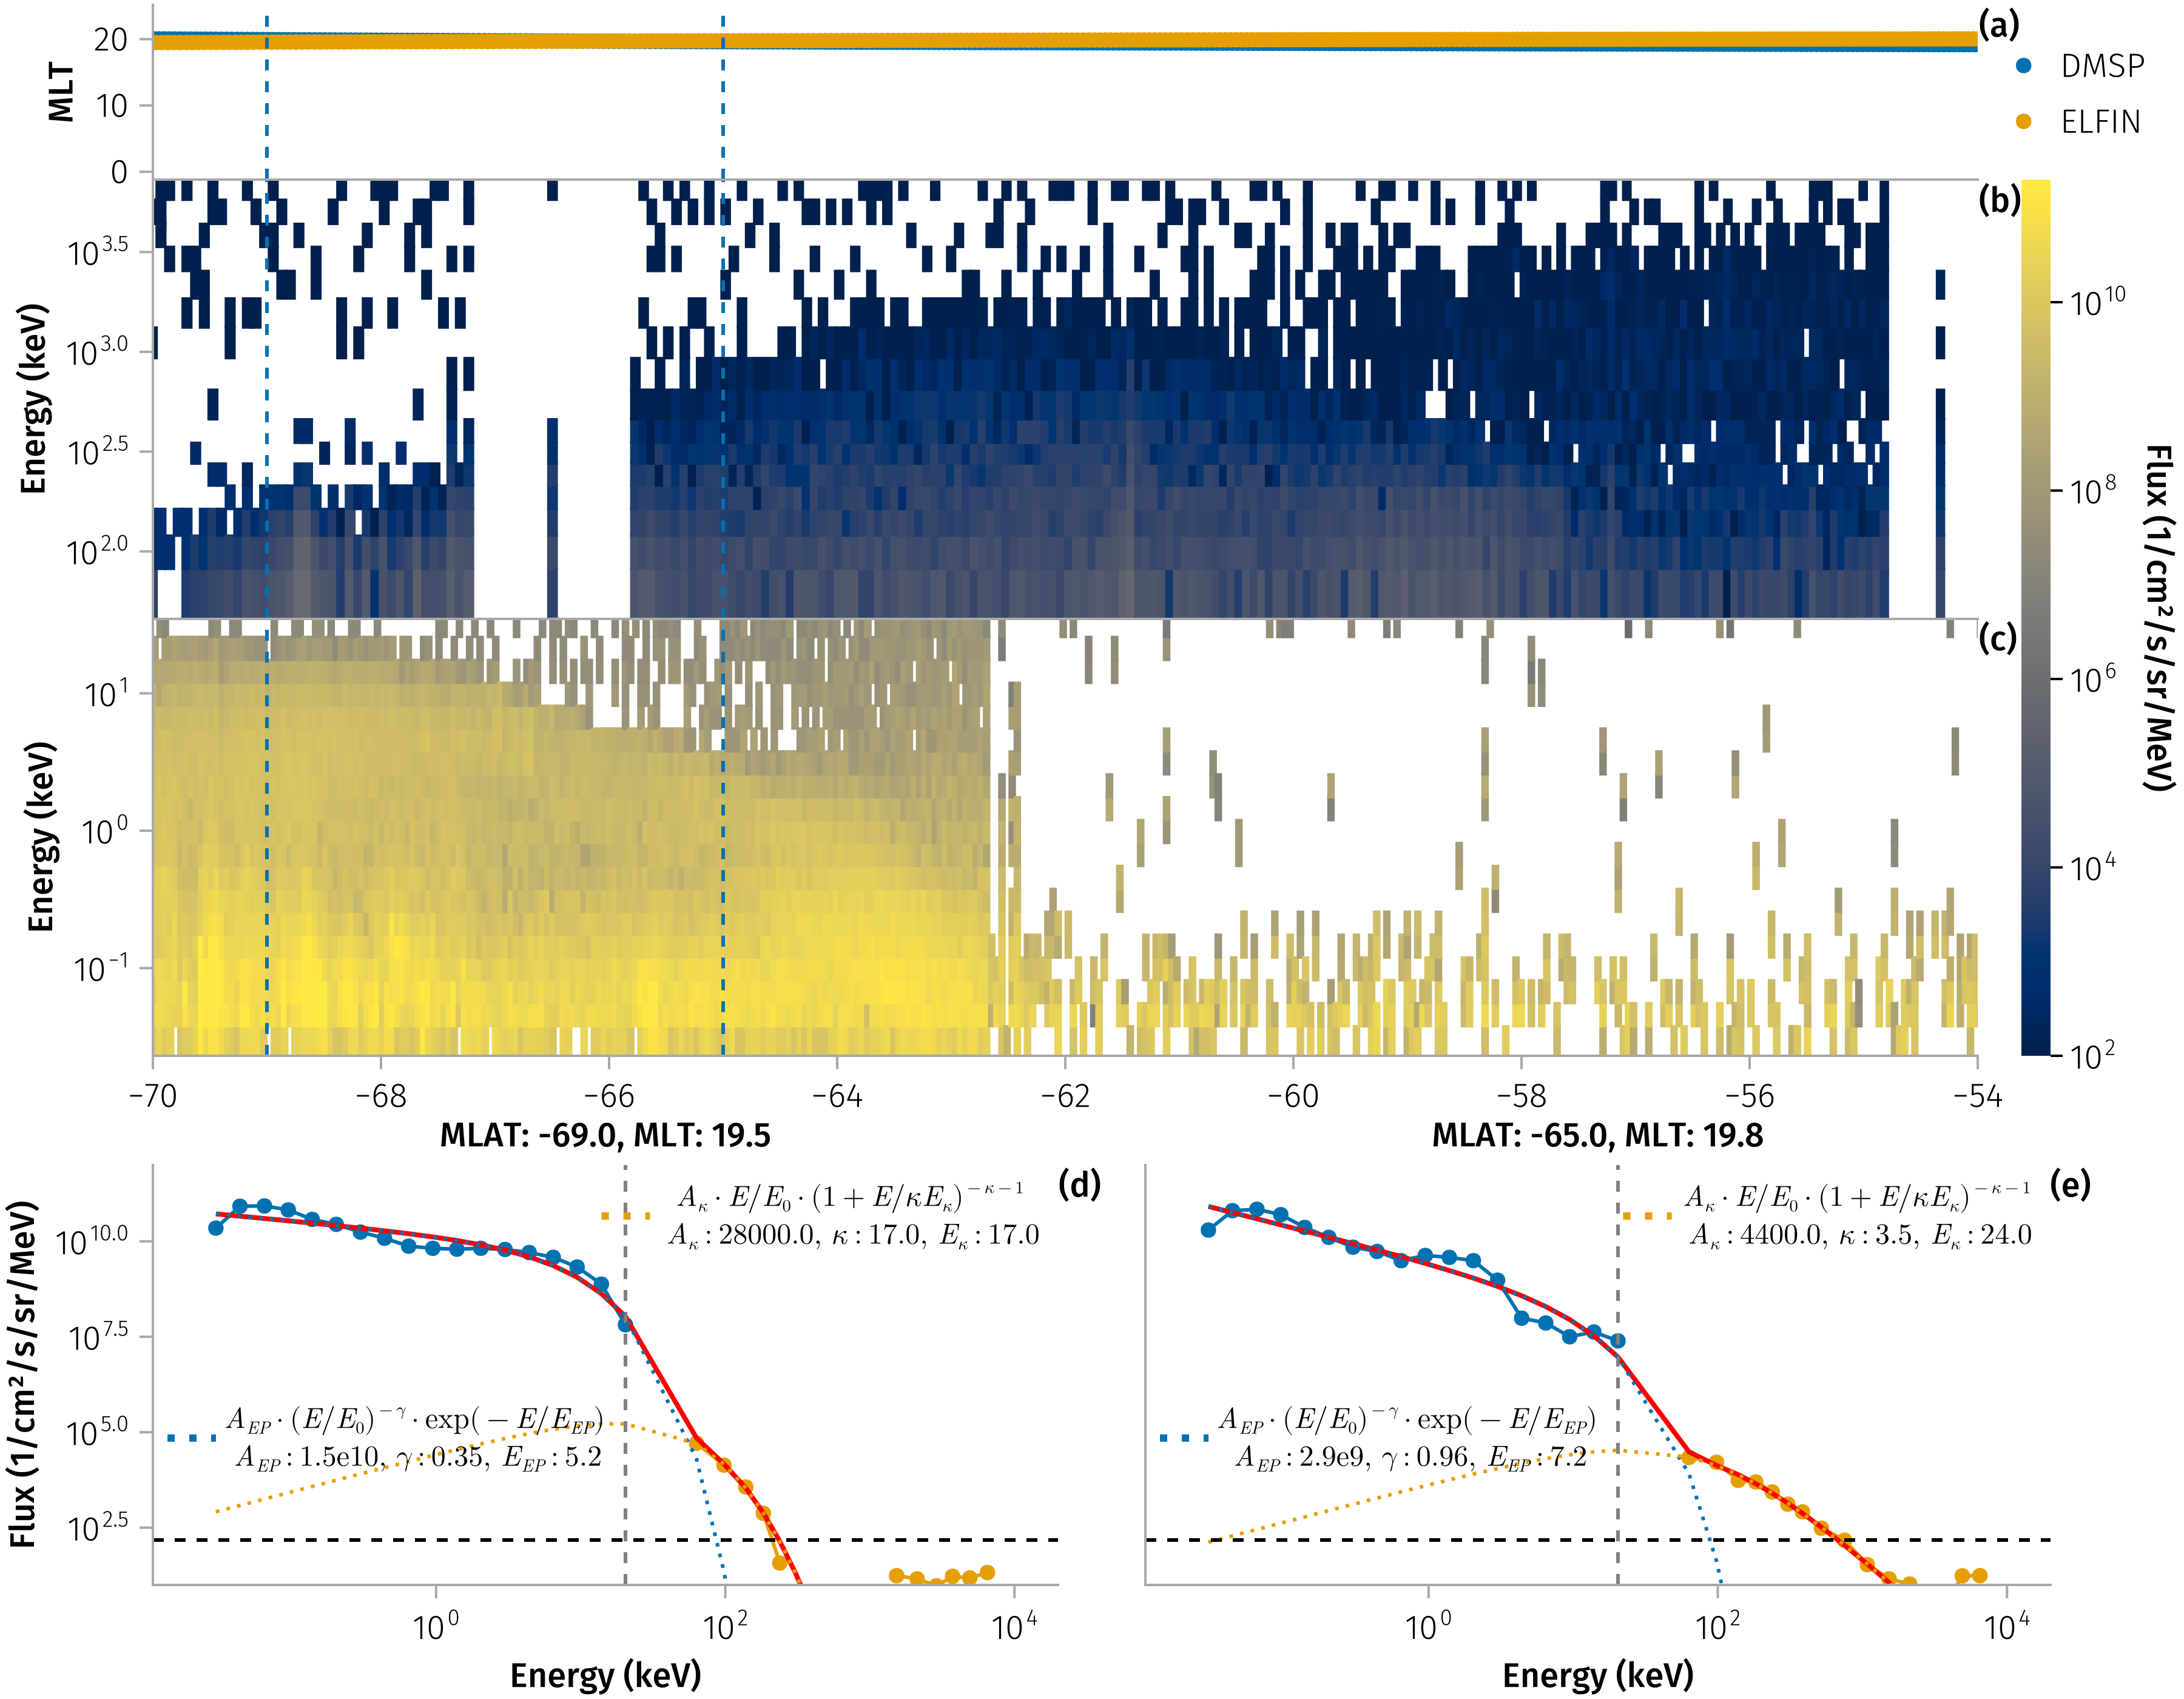

MLAT is used as the primary spatial parameter for characterizing electron precipitation. For each conjunction event, we subdivide the spectral data into 0.5° MLAT bins, average the fluxes within each bin, and combine the measurements from ELFIN and DMSP into a single composite electron flux spectrum. The resulting spectra are fitted using a two-component distribution model, $j(E) = j_{EP}(E) + j_κ(E)$. The low-to-intermediate energy population is represented by an exponential cutoff power-law distribution, which provides greater flexibility than a pure exponential or power-law form alone:

$$
j_{EP}(E) = A_{EP} \left(\frac{E}{E_0}\right)^{-γ}\,\exp\left(-\frac{E}{E_{EP}}\right)
$$

where the reference energy $E_0$ is set to 1 keV. The high-energy population is modeled using a kappa distribution to capture suprathermal tails \[@espinozaIonElectronDistribution2018; @lazarKappaDistributionsObservational2021\]: $j_κ(E) = A_κ \frac{E}{E_0} \left(1 + \frac{E}{κ E_κ}\right)^{-κ-1}$. The fitting procedure minimizes deviations in logarithmic flux space to accurately represent the overall spectral shape.
During this process, we exclude the highest‑energy channel of DMSP, which is occasionally spurious, as well as data points with flux values below the noise threshold $j_{th} = 200 \, \text{cm}^{-2} \cdot \text{s}^{-1} \cdot \text{sr}^{-1} \cdot \text{MeV}^{-1}$. Because direct nonlinear fitting of the full two-component model is numerically unstable, we employ a sequential fitting procedure. First, the high-energy portion of the observed spectrum is fitted independently using the kappa function. After fixing the parameters of this energetic component, the composite model is fitted to the full energy range.
To identify the optimal transition between the two components, we introduce a variable boundary energy, denoted as $E_{\mathrm{trans}}$, which separates the low-energy and high-energy populations. The fitting routine systematically varies $E_{\mathrm{trans}}$ across the available precipitating energy range to evaluate the goodness of fit. The final fit is selected by minimizing the loss function, yielding the best overall representation of the measured spectrum.

To characterize energetic electron contribution to precipitation, we use the total precipitating number flux ($J$) and energy flux ($J_E$) are calculated by integrating the fitted analytic composite distribution over the energy range: $J = \int j(E) dE$ and $J_E = \int j(E) E dE$. The averaged electron energy is then derived as the ratio of total energy flux to total number flux, $\bar{E} = J_E / J$. Fitting the spectral shape allows for reliable interpolation across energy gaps. This method is more robust than direct numerical integration, which is susceptible to bias caused by intermittent instrumental gaps in the observational data. Because the electron spectra also depend on geomagnetic activity, we characterize the magnetospheric conditions using the AE index. Specifically, for each conjunction we consider the AE index within a three-hour window before the observation time and adopt the maximum value within that interval as a representative measure of substorm activity.

## Results

We identified 2,754 conjunction events, yielding a total of 36,380 individual spectral fits from 2020 to 2022. @fig-n illustrates the spatial distribution of these data samples binned by MLT and MLAT. To investigate the influence of geomagnetic activity, the dataset is stratified into three AE index regimes: quiet ($0 \le \text{AE} < 100$ nT), moderate ($100 \le \text{AE} < 300$ nT), and active ($\text{AE} \ge 300$ nT). Owing to the orbital configuration of the DMSP and ELFIN missions, the available observations are concentrated primarily in the dusk sector, followed by the dawn sector.

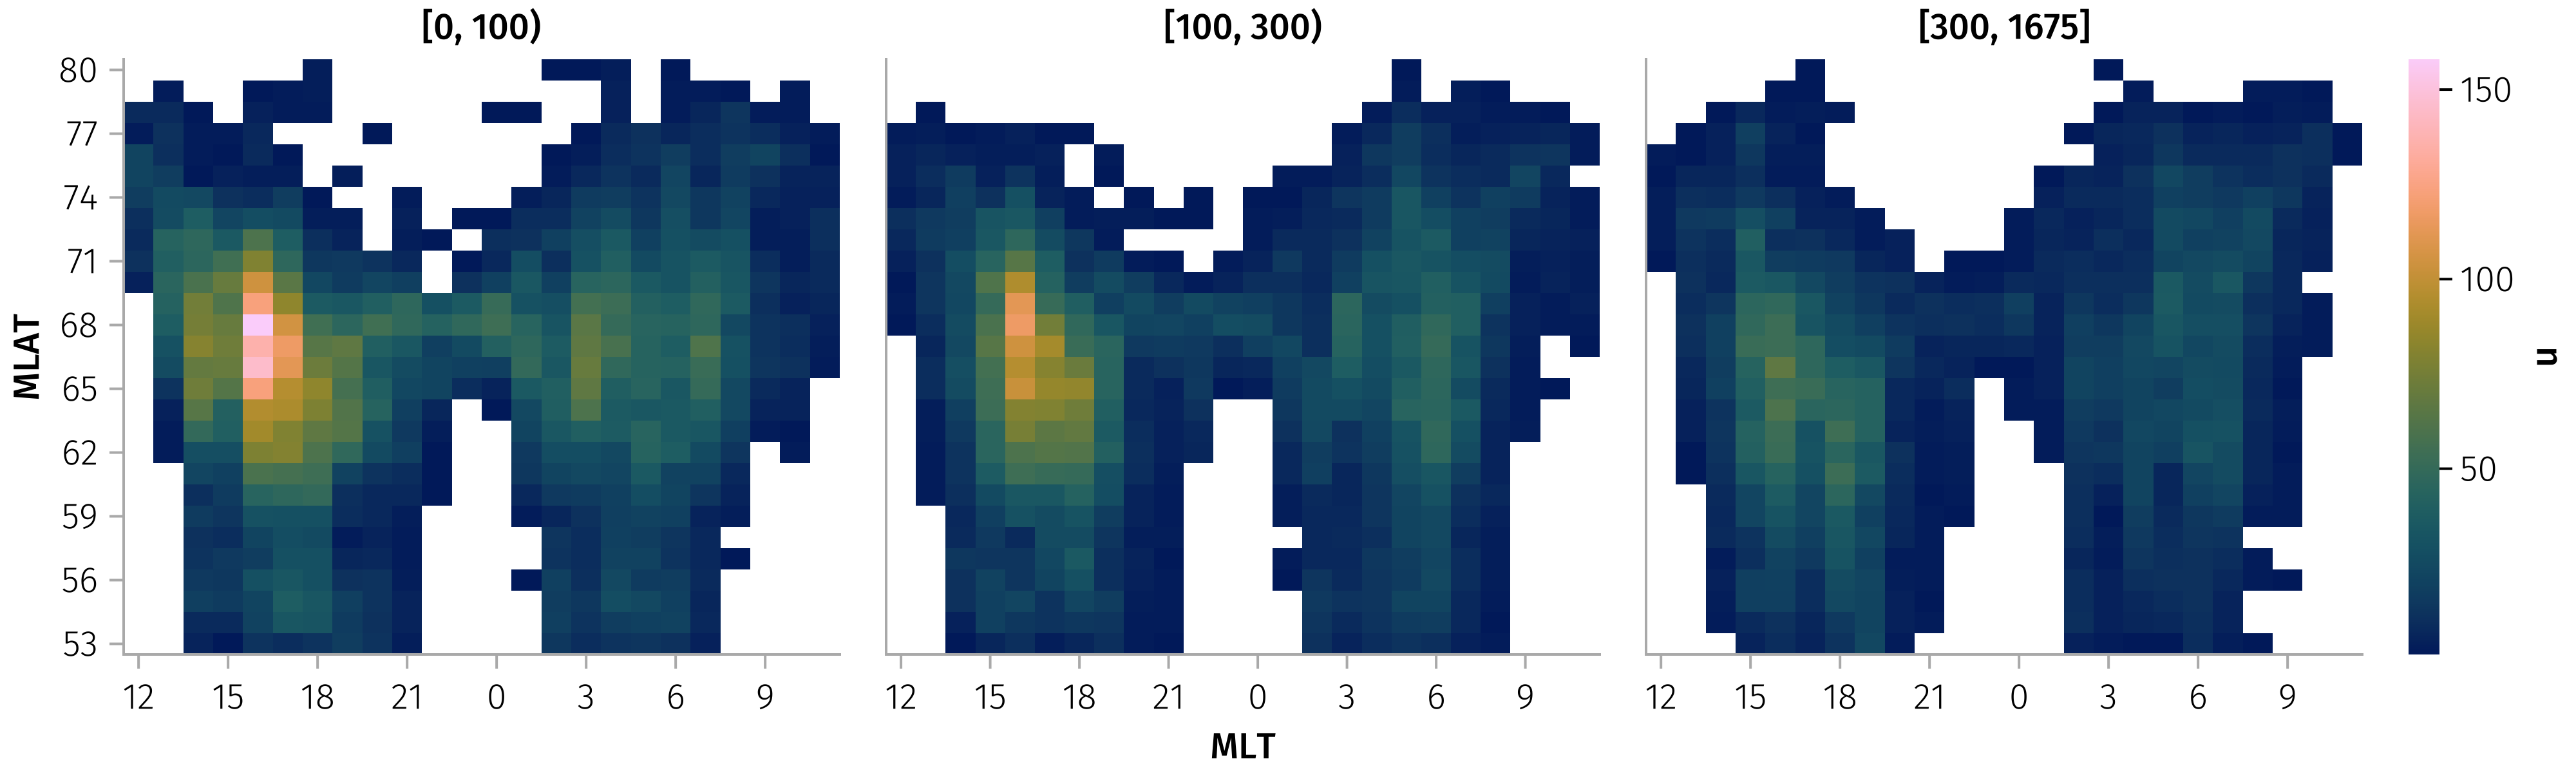{#fig-n }

@fig-e30-ratio presents the distributions of total energy flux, total number flux, and the relative contributions of energetic particles ($>30$ keV) to both number and energy fluxes. These parameters are plotted as functions of MLT and MLAT, categorized by AE index levels.
The results indicate that both total number and energy fluxes exhibit a strong dependence on MLAT, MLT, and geomagnetic activity. The majority of electron precipitation occurs at high magnetic latitudes ($66^{\circ}$ – $80^{\circ}$). Furthermore, precipitation is most intense in the dusk sector, where the overall flux magnitude is largest. However, while the absolute flux in the dawn sector is dominated by the low-energy component, the relative contribution of the energetic population is systematically enhanced in the dusk sector.
Additionally, as shown in the figure, increases in the AE index are accompanied by enhanced total energy and number fluxes, with the region of significant precipitation expanding toward lower magnetic latitudes and a broader MLT range. In contrast, the fractional contribution of the energetic component decreases during periods of high AE activity relative to quieter intervals.

In [0]:
_make_tdf(gdf, func, vars; n=6) = @chain gdf begin
    combine(_variable.(vars) .=> func, nrow => :n, renamecols=false)
    dropmissing!
    @rsubset(:n >= n)
end

let vars = [:JE_tot => log10 => L"(a) $J_E$: Energy flux", :J_tot => log10 => L"(b) $J$: Number flux", :R_JE_e30 => L"(c) $J_E^{>30 \text{keV}} / J_E$", :R_J_e30 => L"(d) $J^{>30 \text{keV}} / J$"], axis = m2axis, func = median
    f = Figure(; size=(720, 540))
    tdf = _make_tdf(gdf, func, vars)
    plot_params_variation(f, tdf, vars; axis)
    colgap!(f.layout, 4)
    rowgap!(f.layout, 4)
    easy_save("e30_flux_ratio_mlt_mlat_$(func)")
end

![Median distributions of (a) total energy flux \[$\text{keV} \cdot \text{cm}^{-2} \cdot \text{s}^{-1} \cdot \text{sr}^{-1}$\], (b) total number flux \[$\text{cm}^{-2} \cdot \text{s}^{-1} \cdot \text{sr}^{-1}$\], and (c-d) the fractional contribution of energetic particles ($>30$ keV) to the total energy flux and total number flux. All parameters are plotted as functions of MLT and MLAT, stratified by AE index levels.](attachment:./figures/e30_flux_ratio_mlt_mlat_median.png){#fig-e30-ratio }

@fig-param presents the kappa parameter ($\kappa$) and averaged energy ($\bar{E}$) as functions of MLT and MLAT, sorted by AE index levels. As shown in the figure, the average electron energy exhibits a strong dependence on MLT, MLAT, and the AE index. While average energy varies significantly with all three parameters, the kappa parameter shows a comparatively weaker dependence on MLT and the AE index, but a stronger dependence on MLAT.
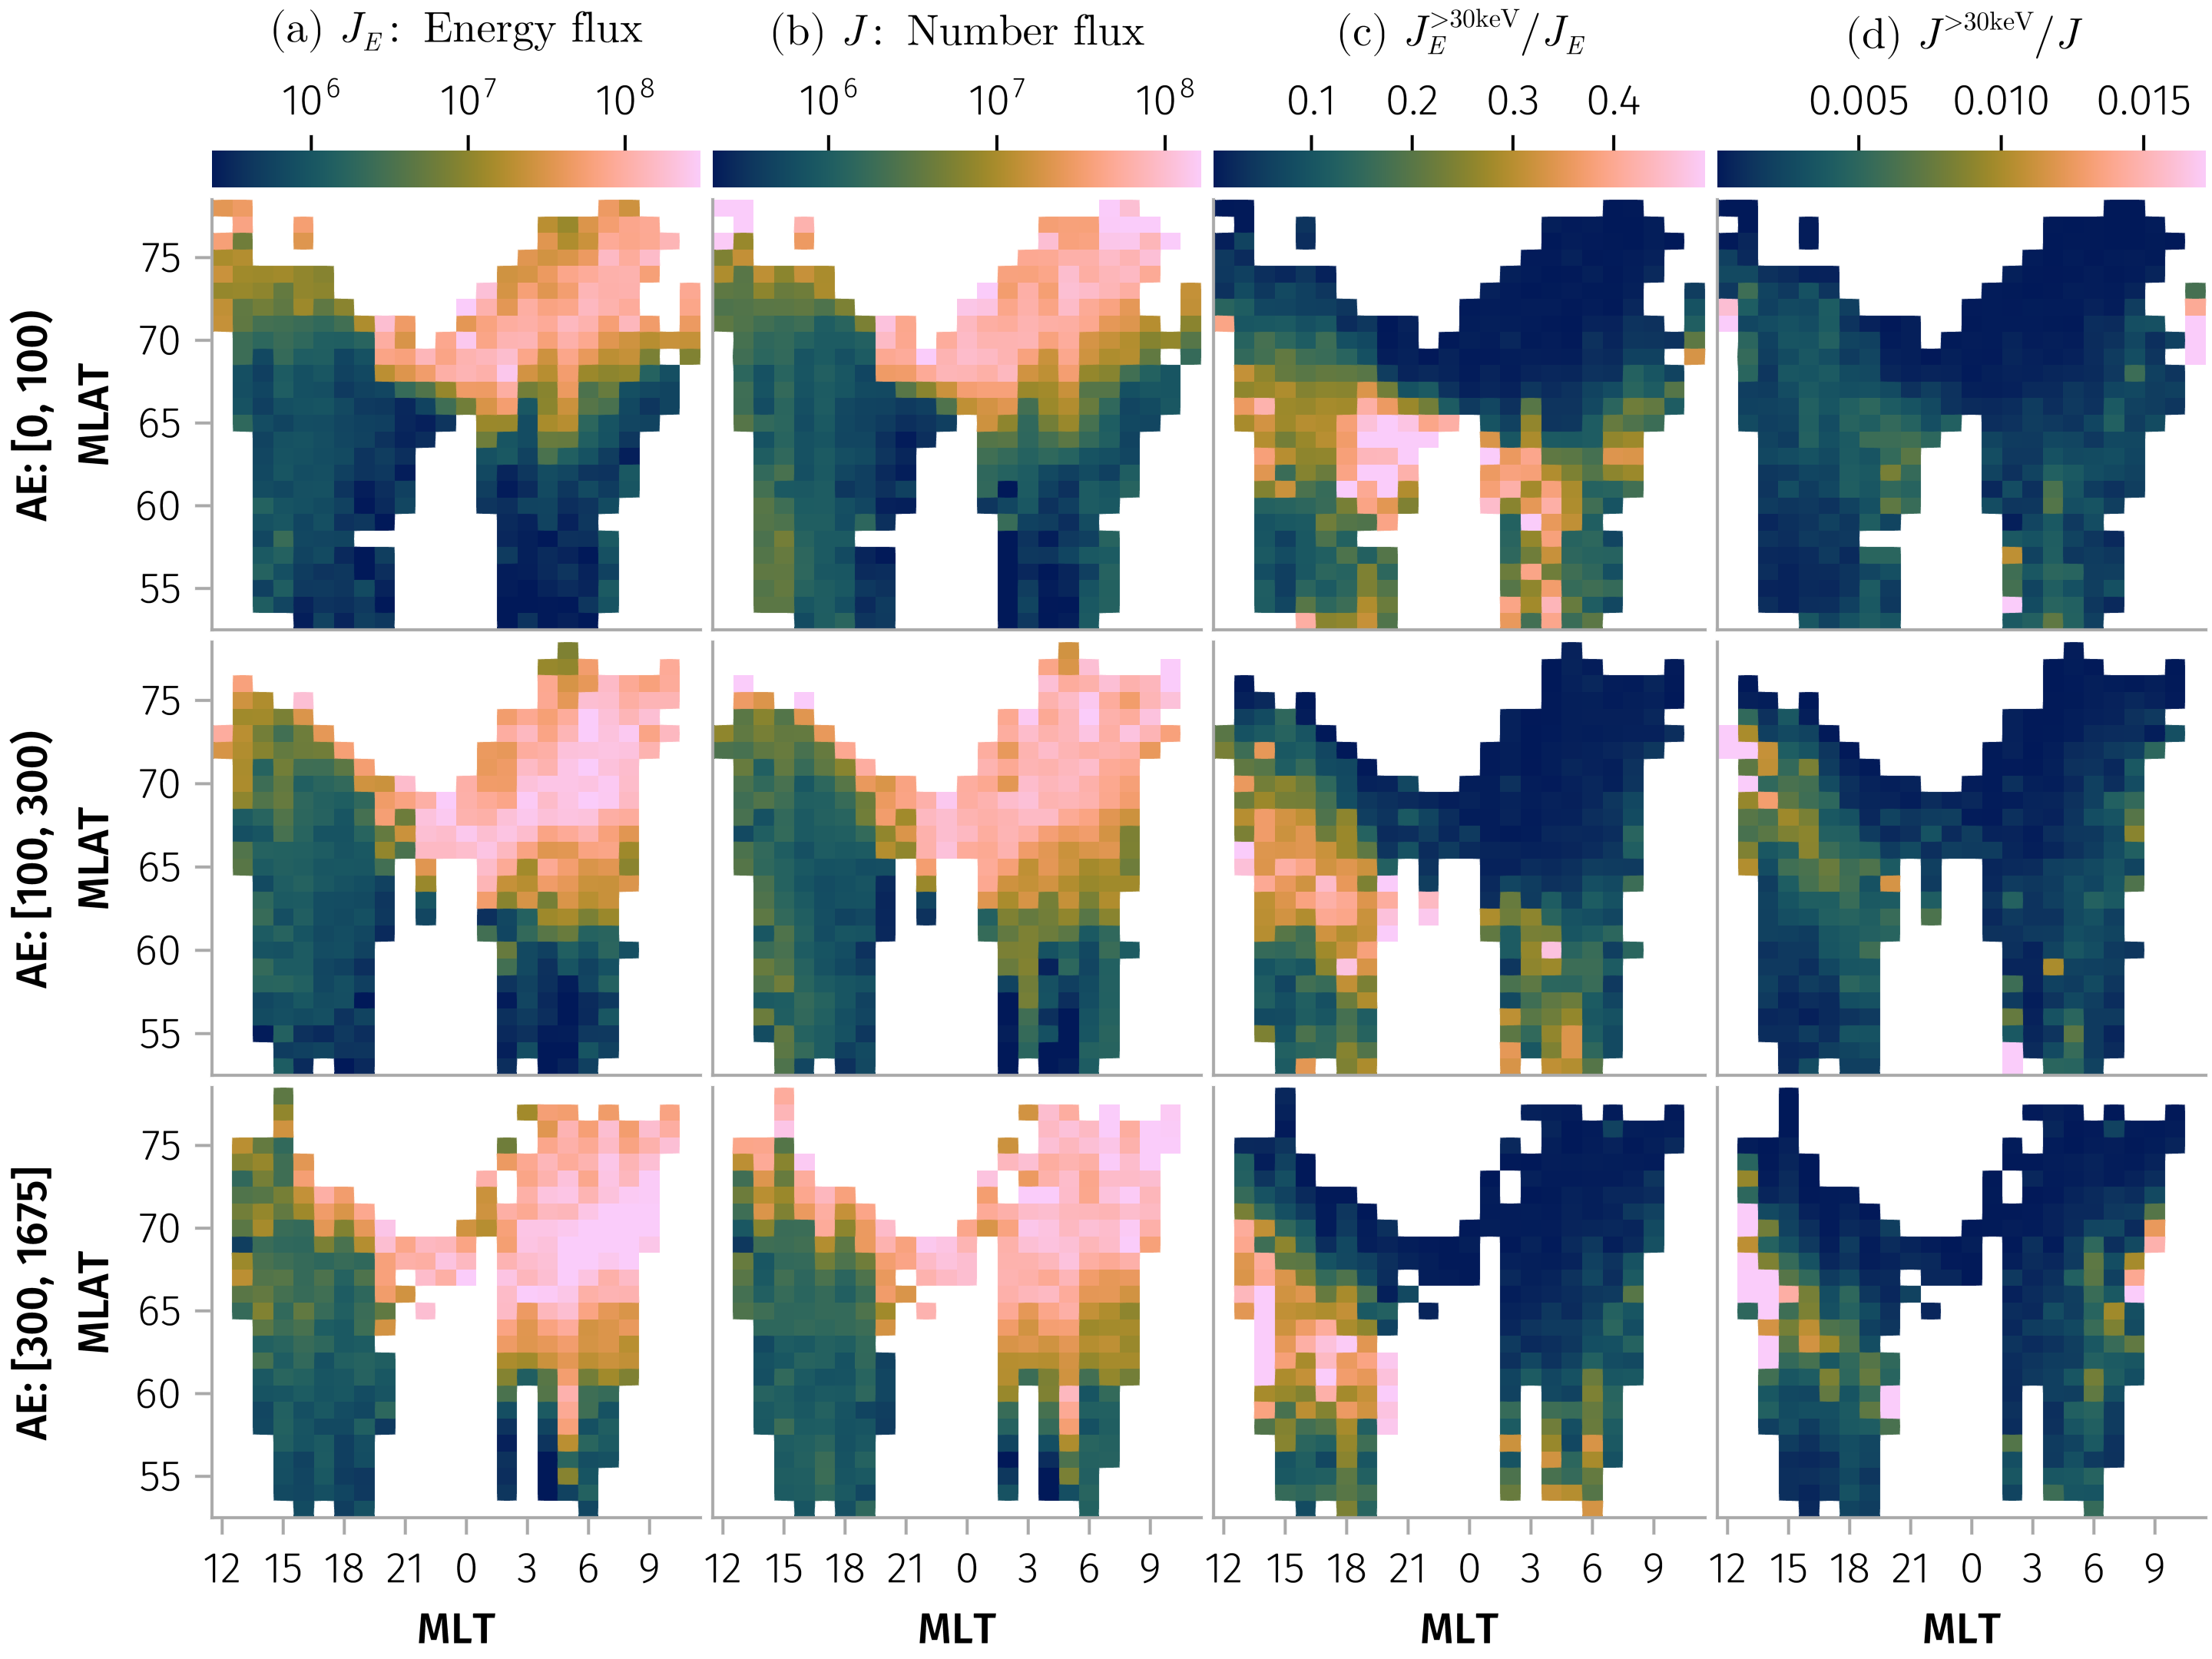

In [0]:
let axis = m2axis, func = median
    vars = [:E => L"(a) $\bar{E}$: Averaged energy", :κ => L"(b) $\kappa$: Kappa parameter"]
    colorranges = (; E=(0.1, 5.5), κ=(1.8, 6.1))
    f = Figure(; size=(450, 540))
    tdf = _make_tdf(gdf, func, vars)
    plot_params_variation(f, tdf, vars; axis, colorranges)
    colgap!(f.layout, 4)
    rowgap!(f.layout, 4)
    easy_save("key_params_mlt_mlat_$(func)")
end

![Median distributions of (a) averaged energy ($\bar{E}$) \[$\text{keV}$\] and (b) kappa parameter ($\kappa$) as functions of MLT and MLAT, sorted by AE index levels.](attachment:./figures/key_params_mlt_mlat_median.pdf){#fig-param }

To better interpret the spatial variability of energetic electron spectral properties in MLAT–MLT space, we examine probability density functions (PDFs for four ranges of MLT and MLAT). Specifically, we define four representative regions: two MLT sectors, post-midnight and dusk (0–9 and 12–21), and two MLAT ranges ((60<sup>{})–(65</sup>{}) and (\>65^{})), corresponding to sub-auroral and auroral latitudes, respectively. These four MLAT–MLT regions are analyzed for three ranges of the AE index. For each (MLAT, MLT, AE) combination, we evaluate PDFs of (i) the fractional contribution of energetic electrons to the total energy flux ((J_E^{\>30,} / J_E)), (ii) the average electron energy (({E})), and (iii) the kappa parameter (()), as shown in @fig-param-pdf.

Under conditions of low geomagnetic activity, the distribution of (J_E^{\>30,} / J_E) is strongly peaked at small values at auroral latitudes in the post-midnight sector, where plasma sheet electrons with energies below 30 keV dominate the precipitating energy flux. In contrast, for other MLAT and MLT regions, the distributions are broader and largely similar. With increasing geomagnetic activity, the contribution of energetic electrons to the total energy flux remains nearly unchanged—or even increases—in the dusk sector, whereas in the post-midnight sector it decreases at both sub-auroral and auroral latitudes. Overall, @fig-param-pdf (top row) demonstrates that energetic electron precipitation should not be neglected in the sub-auroral region and can also be significant in the auroral region on the dusk side, where it may account for up to 80% of the total precipitating energy flux.

Average-energy distributions are generally concentrated at low values, with ({E} \< 3) keV, but they exhibit distinct responses to geomagnetic activity in the post-midnight sector and on the dusk flank. On the dusk flank, increasing AE is associated with the development of a pronounced long tail in the ({E}) distribution, extending up to ({E} 10) keV. In contrast, in the post-midnight sector, the ({E}) distribution remains confined to ({E} \< 5) keV as AE increases, although it becomes flatter within the ({E} \< 3) keV range. Overall, Figure~ (middle row) indicates that, across all MLAT and MLT sectors, there is a non-negligible—particularly during geomagnetically active periods—probability of observing ({E} \> 5) keV. In such cases, the DMSP energy range ((\<30) keV) alone is insufficient to fully capture the precipitating energy flux.

The distributions of () values vary primarily with AE and show pronounced differences between auroral and sub-auroral latitudes, whereas differences between the post-midnight sector and the dusk flank are comparatively modest. At auroral latitudes ((\>65^)), the () distributions are broader, indicating a higher probability of large () values, than at sub-auroral latitudes. Moreover, increasing AE leads to broader () distributions across all latitudinal ranges. We note that, given the limited energy range used to fit the energetic electron population, spectra with (\> 4) (corresponding to (\> 5) for phase-space density) can be regarded as approximately Maxwellian.

As geomagnetic activity increases, the distributions of $J_E^{>30 \text{keV}} / J_E$ shift toward lower values in the MLT 0–9 sector, whereas this shift is less pronounced in the MLT 12–21 sector. Similarly, with increasing AE, the distributions of average energy ($\bar{E}$) shift substantially toward higher energies in the MLT 0–9 sector, while only a slight increase is observed in the MLT 12–21 sector.

The distributions of $\kappa$ are generally broader and centered at higher values at high latitudes ($>65^{\circ}$) compared to lower latitudes. Notably, in the MLT 0–9 sector, $\kappa$ exhibits a bimodal distribution, which may be interpreted as \[… ANTON HELP\]. As the AE index increases, this bimodality becomes more pronounced, and even the low-latitude region ($60^{\circ}$–$65^{\circ}$) begins to exhibit a bimodal structure during periods of enhanced geomagnetic activity (AE $> 300$ nT). In contrast, the $\kappa$ distribution in the MLT 12–21 sector remains relatively stable and unimodal, showing only slight broadening with increasing AE.

In [0]:
# Transform dataframe with range categories
let params = [:R_JE_e30 => L"$J_E^{>30 \text{keV}} / J_E$", :E => L"$\bar{E}$ [keV]", :κ => L"$κ$",]
    labels = last.(params)
    pdf_df = @chain cut_AE(sdf) begin
        @rtransform(
            :MLT = ifelse(12 <= :mlt_elx <= 21, "12-21", :mlt_elx < 9 ? "0-9" : missing),
            :MLAT = 60 <= abs(:mlat) < 65 ? "60-65" : (abs(:mlat) >= 65 ? ">65" : missing)
        )
        dropmissing([:maxAE_bin, :MLT, :MLAT])
    end

    plt = data(pdf_df) *
          mapping(params, color=:MLAT, linestyle=:MLT) *
          mapping(col=:maxAE_bin, row=AlgebraOfGraphics.dims(1) => renamer(labels)) *
          visual(Lines; linewidth=2) *
          AlgebraOfGraphics.density(; datalimits=x -> quantile(x, [0.04, 0.96]))

    fg = draw(plt; facet=(; linkxaxes=:none, linkyaxes=:minimal), axis=(xlabel="", yscale=log10))

    Makie.xlims!.(fg.grid[1, :], -0.05, 0.9)
    Makie.xlims!.(fg.grid[2, :], -0.2, 12)
    Makie.ylims!.(fg.grid[2, :], 10^(-2.4), 10^(-0.2))
    Makie.xlims!.(fg.grid[3, :], 1, 7.8)
    easy_save("pdf_params_ae_mlt_mlat")
end

![Probability density functions of (a) the energy flux ratio $J_E^{>30\text{keV}}/J_E$, (b) the mean energy $\bar{E}$ \[keV\], and (c) the kappa parameter $\kappa$. Distributions are organized by three AE index ranges (0–100, 100–300, and $>300$ nT), two MLT sectors (12–21 and 0–9), and two MLAT bands ($60^{\circ}$–$65^{\circ}$ and $>65^{\circ}$).](attachment:./figures/pdf_params_ae_mlt_mlat.pdf){#fig-param-pdf }

## Summary

In this study, we present a new dataset of precipitating electron fluxes spanning an extended energy range of $10^2$–$10^6$ eV.
The dataset is constructed using conjunction observations from two ELFIN CubeSats and three DMSP satellites during the period 2020–2022. It comprises approximately $3.6 \times 10^{4}$ individual electron spectra, each fitted with a combination of Maxwellian and power-law distributions to interpolate the energy gap between the DMSP and ELFIN measurements.

Building on this dataset, we developed an empirical, data-driven model (described in detail in the Appendix) to characterize precipitating electron fluxes from the thermal regime ((100) eV, DMSP) to relativistic energies ((1) MeV, ELFIN). This model extends the energy coverage of previous frameworks and provides a more comprehensive representation of the full spectrum of precipitating electrons.

We also analyzed the basic properties of the combined DMSP–ELFIN precipitating electron spectra. Our main findings are summarized as follows:

-   The contribution of energetic electrons to the total precipitating energy flux can reach, on average, (40%), and for individual events can be as high as (80%). Such large contributions are most frequently observed on the dusk flank at sub-auroral latitudes, while a significant average contribution is also present in the post-midnight sector.
-   The average electron energy is maximized in the post-midnight sector and reaches, on average, (5) keV, whereas for individual events on the dusk flank it can be as large as (10) keV.
-   The energetic component of precipitating electron spectra is well described by a power-law distribution with (\< 3) at sub-auroral latitudes and (\> 3) (corresponding to nearly Maxwellian spectra) at auroral latitudes.

Overall, these results underscore the importance of accounting for energetic electron contributions in studies of magnetosphere–ionosphere coupling. Accurate modeling of this component is essential, as its contribution varies with MLAT, MLT, and geomagnetic activity in ways that differ substantially from those of electrons with energies below 30 keV.

## Data Availability

The processing and analysis software used in this manuscript is available on GitHub at https://github.com/Beforerr/dmsp_elfin. ELFIN data were accessed using the ELFINData.jl package, and DMSP observations were obtained from the Madrigal database via the DMSPData.jl package.
We gratefully acknowledge the ELFIN and DMSP teams for providing these datasets that make this study possible.
We acknowledge the use of the IRBEM library (version 5.0.0), the latest version of which can be found at https://doi.org/10.5281/zenodo.6867552.

## Appendix: Data Products

This study provides two primary data products for community use:

1.  Event Catalog: We provide a tabulated catalog of all identified conjunction events. For each event, the table includes the observation time, the corresponding measurements from DMSP and ELFIN, the precipitating electron fluxes observed by both satellites, and the parameters of the fitted composite spectral model.

2.  Software Library: To facilitate the application of our results, we developed the DEEEP (Dmsp Elfin Energetic Electron Precipitation) software library. This tool allows users to predict precipitating electron energy flux under specified geophysical conditions. Given inputs of Magnetic Local Time (MLT), Magnetic Latitude (MLAT), and the AE index, the library returns a spectral function mapping electron energy to differential number flux. The library is implemented in Julia with Python bindings available.

An example demonstrating the usage of this library in Julia is shown below:

``` julia
using PrecipitatingFluxModels

# Initialize the model
model = load_model()

# Evaluate flux at specific geophysical conditions:
# Location: 65° MLat, 6 MLT (dawn sector)
# Activity: Moderate (AE = 150 nT)
submodel = model(; mlat=65.0, mlt=6.0, ae=150.0) # Returns a function of energy

# Calculate flux at a specific energy (e.g., 10 keV)
E = 10.0 # [keV]
flux_10keV = submodel(E)

# Generate the full energy spectrum
energies = 10 .^ range(log10(0.03), log10(1000), length=100)  # 0.03 - 1000 keV
spectrum = submodel.(energies)

# Compute integrated fluxes across the spectrum
Emin = 0.03
Emax = 100.0
J  = n_flux(submodel, Emin, Emax)  # Number flux [cm⁻² s⁻¹ sr⁻¹]
JE = e_flux(submodel, Emin, Emax)  # Energy flux [keV cm⁻² s⁻¹ sr⁻¹]
```

In [0]:
using CSV
using PrecipitatingFluxModels

CSV.write("files/tranges.csv", tranges)

PrecipitatingFluxModels.save(
    PrecipitatingFluxModels.create_model_from_stats(sdf)
)